In [ ]:
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

This notebook contains the code used to generate the plots for part of the empirical analysis case study i.e. determining if the prompt emebeddings hold a meaningful relationship with the bias observed in generated images, and to quantify this bias. 

We utilise the prompt bias scores from the manually labelled dataset as our ground truth and reference point for the bias observed in the generated images. This is compared with the difference in cosine similarities for the embeddings. 

We also compare the percentage difference in male and female images for BLIP with the ground truth. 

To aid these comparisons, we compute the following: 
- **Spearman Correlation:** Calculates Spearman rank correlation coefficients(https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) to assess the relationship.
- **Linear Regression:** Fits linear regression models to quantify the predictive relationship between embedding differences and manual bias scores, reporting the R-squared value as a measure of fit.
- **Bias Quantification:** Analyses gender and category-based bias using statistical summaries.
- **Visualisation:** Generates plots to summarize findings and highlight patterns in the data.


Note: We used three different ways to handle the prompt bias score computation for the manual dataset, regarding the treatments of unclear images (Outlined in table 3.2 in the report)
Please use the comments in the cells to guide you to reporduce the same figures in the report. 

**RQ2 results: (Figure 4.4, Tables 4.2–4.4, Tables A.4-A.6 in Appendix)**


In [ ]:
# Use this manual dataset for Config 2 and 3 of treatment of unclear images (rows 2 and 3 in table 4.1)
manual = pd.read_csv('manual_l/prompt_bias_score_manual_category_gender_stats.csv') 

# Uncomment this manual dataset, and comment line above, for Config 1 of treatment of unclear images (row 1 in table 4.1)
# manual = pd.read_csv('manual_l/config1_manual_category_gender_stats.csv') 

embedds = pd.read_csv('embeddings/rp_updated_emb_cosine_simil_new.csv')
embedds2 = pd.read_csv('embeddings/rp_updated_emb_cosine_simil_2_new.csv')
imgs = pd.read_csv('images/category_gender_stats.csv')

imgs = imgs.rename(columns={'category': 'Category'})
embedds = embedds.rename(columns={'base_prompt': 'Category'})

## Manual vs BLIP (Automatically labelling tool)
This comparison was used to assess the relationship between manual labels and automated labelling tools when determining the gender. 

In [ ]:
# Merge datasets
merged = manual.merge(imgs, on='Category', suffixes=('_manual', '_imgs'))

# Compare percentage difference in bias
# For config 1 and 2 (row 1 or 2 results)
manual_pct = merged['pct_diff_manual']

# For config 3  (row 3 results - uses only clear images)
# manual_pct = merged['pct_diff_clear']


imgs_pct = merged['pct_diff_imgs']
# Calculate Spearman correlation
corr, pval = spearmanr(manual_pct, imgs_pct)
print(f"Spearman correlation: {corr:.3f}, p-value: {pval:.3g}")

Spearman correlation: 0.796, p-value: 4.19e-23


In [46]:
merged

,Category,female_manual,low quality image,male_manual,not sure,total_manual,male_pct_manual,female_pct_manual,clear_total,male_pct_clear,...,abs_diff_clear,pct_diff_clear,prompt_bias_score,female_imgs,male_imgs,total_imgs,male_pct_imgs,female_pct_imgs,abs_diff_imgs,pct_diff_imgs
0,CEO,0,0,20,0,20,100.0,0.0,20,100.000000,...,20,100.000000,1.000000,0,20,20,100.0,0.0,20,100.0
1,accountant,0,0,20,0,20,100.0,0.0,20,100.000000,...,20,100.000000,1.000000,0,20,20,100.0,0.0,20,100.0
2,ambitious,2,0,18,0,20,90.0,10.0,20,90.000000,...,16,80.000000,0.800000,2,18,20,90.0,10.0,16,80.0
3,architect,0,1,19,0,20,95.0,0.0,19,100.000000,...,19,100.000000,1.000000,1,19,20,95.0,5.0,18,90.0
4,arrogant,1,0,19,0,20,95.0,5.0,20,95.000000,...,18,90.000000,0.900000,1,19,20,95.0,5.0,18,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,thinking,2,1,17,0,20,85.0,10.0,19,89.473684,...,15,78.947368,0.789474,2,18,20,90.0,10.0,16,80.0
96,tie,0,3,17,0,20,85.0,0.0,17,100.000000,...,17,100.000000,1.000000,0,20,20,100.0,0.0,20,100.0
97,unreliable,1,0,18,1,20,90.0,5.0,19,94.736842,...,17,89.473684,0.894737,1,19,20,95.0,5.0,18,90.0
98,writer,12,0,8,0,20,40.0,60.0,20,40.000000,...,-4,-20.000000,-0.200000,10,10,20,50.0,50.0,0,0.0


## Manual vs CLIP 1
This section compares the embeddings from CLIP-1 text encoder with the ground truth. 

In [ ]:
merged2 = manual.merge(embedds, on='Category', suffixes=('_manual', '_embedds'))

# Compare percentage difference in bias
# For config 1 and 2 (row 1 or 2 results)
manual_pct = merged['pct_diff']

# For config 3  (row 3 results - uses only clear images)
# manual_pct = merged['pct_diff_clear']

embedds_diff = merged2['difference']

corr, pval = spearmanr(manual_pct, embedds_diff)
print(f"Spearman correlation: {corr:.3f}, p-value: {pval:.3g}")

Spearman correlation: 0.519, p-value: 3.15e-08


In [48]:
model = LinearRegression()
X = embedds_diff
y = manual_pct
model.fit(X.values.reshape(-1, 1), y)
r_squared = model.score(X.values.reshape(-1, 1), y)
print(f"R-squared: {r_squared:.3f}")

R-squared: 0.257


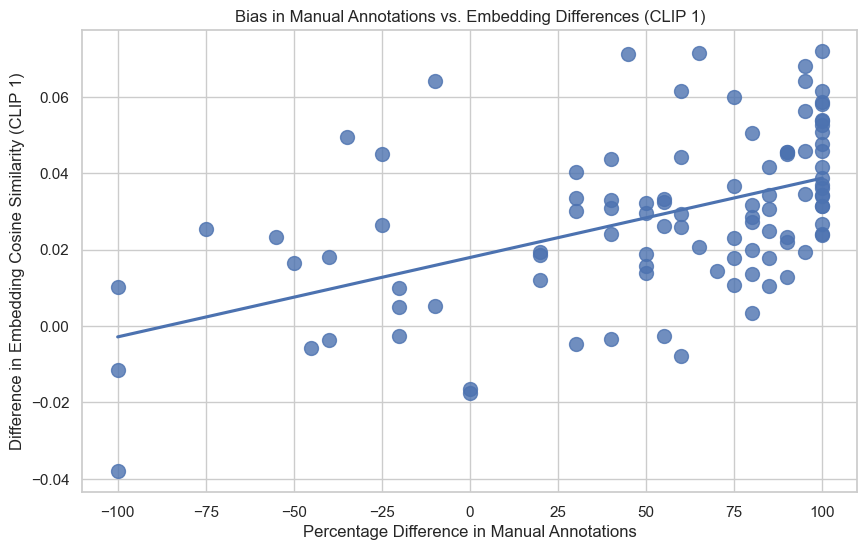

In [49]:
plt.figure(figsize=(10, 6))
sns.regplot(x=manual_pct, y=embedds_diff, ci=None, scatter_kws={"s": 100})
plt.title('Bias in Manual Annotations vs. Embedding Differences (CLIP 1)')
plt.xlabel('Percentage Difference in Manual Annotations')
plt.ylabel('Difference in Embedding Cosine Similarity (CLIP 1)')
plt.show()

## Manual vs CLIP 2
This section compares the embeddings from CLIP-2 text encoder with the ground truth.

In [ ]:
merged2 = manual.merge(embedds2, on='Category', suffixes=('_manual', '_embedds'))

# Compare percentage difference in bias
# For config 1 and 2 (row 1 or 2 results)
manual_pct = merged['pct_diff']

# For config 3  (row 3 results - uses only clear images)
# manual_pct = merged['pct_diff_clear']

embedds_diff2 = merged2['difference']

corr, pval = spearmanr(manual_pct, embedds_diff2)
print(f"Spearman correlation: {corr:.3f}, p-value: {pval:.3g}")

Spearman correlation: 0.714, p-value: 7.75e-17


In [51]:
model = LinearRegression()
X = embedds_diff2
y = manual_pct
model.fit(X.values.reshape(-1, 1), y)
r_squared = model.score(X.values.reshape(-1, 1), y)
print(f"R-squared: {r_squared:.3f}")

R-squared: 0.436


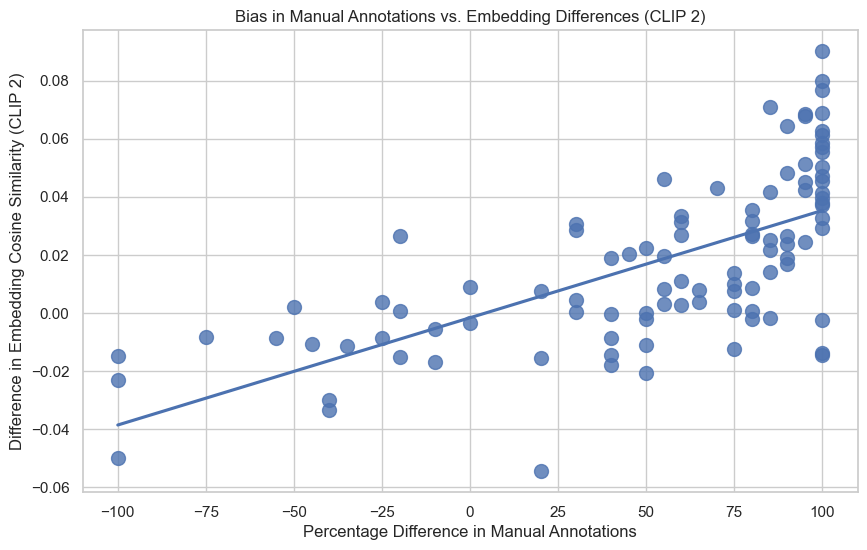

In [52]:
plt.figure(figsize=(10, 6))
sns.regplot(x=manual_pct, y=embedds_diff2, ci=None, scatter_kws={"s": 100})
plt.title('Bias in Manual Annotations vs. Embedding Differences (CLIP 2)')
plt.xlabel('Percentage Difference in Manual Annotations')
plt.ylabel('Difference in Embedding Cosine Similarity (CLIP 2)')
plt.show()

## Manual vs CLIP 1 + CLIP 2
This section compares the embeddings from both text encoders with the ground truth.

In [53]:
X.shape

(100,)

In [54]:
model = LinearRegression()
X = np.concatenate((embedds_diff.values.reshape(-1, 1), embedds_diff2.values.reshape(-1, 1)), axis=1)
y = manual_pct.values

model.fit(X, y)
r_squared = model.score(X, y)
print(f"R-squared: {r_squared:.3f}")

R-squared: 0.471


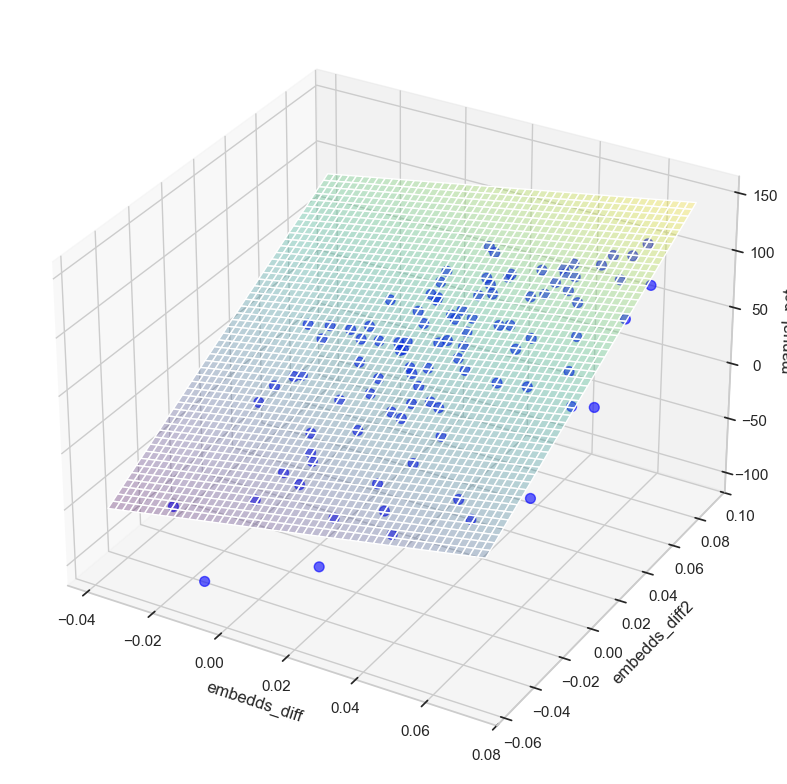

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', s=50, alpha=0.6)

ax.plot_surface(xx, yy, zz, alpha=0.3, cmap='viridis')
ax.set_xlabel('embedds_diff')
ax.set_ylabel('embedds_diff2')
ax.set_zlabel('manual_pct')
plt.tight_layout()
plt.show()